# Double Exponential (Laplace) Distribution

The **Double Exponential (Laplace) distribution** looks like two Exponential distributions placed back-to-back. It is symmetric like the Normal but has a sharper peak and **heavier tails** (kurtosis=6 vs 3). It arises in L1 regression (least absolute deviations) and is the likelihood model behind the LASSO regulariser.

| Property | Value |
|---|---|
| **Parameters** | μ (location), β (scale, β > 0) |
| **Support** | (−∞, +∞) |
| **PDF** | f(x) = (1/2β) exp(−|x−μ|/β) |
| **CDF** | F(x) = 0.5 + 0.5 · sign(x−μ)(1 − exp(−|x−μ|/β)) |
| **Mean** | μ |
| **Median** | μ |
| **Std Dev** | √2 · β |
| **Skewness** | 0 (symmetric) |
| **Kurtosis** | 6 (heavier tails than Normal) |
| **Estimation** | μ̂ = sample median (MLE); β̂ = mean(|xᵢ − μ̂|) |
| **LASSO link** | Laplace prior on coefficients → L1 regularisation |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

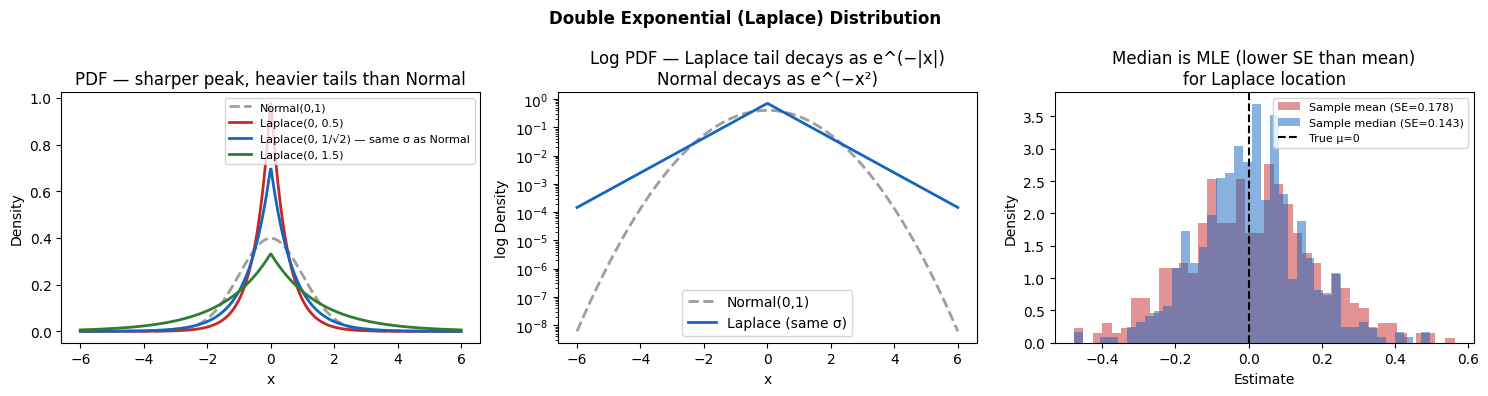

MLE for Laplace is the sample median (not the mean)
Mean SE=0.1782  vs  Median SE=0.1434


In [2]:
x = np.linspace(-6, 6, 500)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Double Exponential (Laplace) Distribution', fontsize=12, fontweight='bold')

# PDF vs Normal
axes[0].plot(x, stats.norm(0,1).pdf(x), color='#9E9E9E', linewidth=2, linestyle='--', label='Normal(0,1)')
for beta, color, label in [(0.5, '#C62828', 'Laplace(0, 0.5)'),
                             (1/np.sqrt(2), '#1565C0', 'Laplace(0, 1/√2) — same σ as Normal'),
                             (1.5, '#2E7D32', 'Laplace(0, 1.5)')]:
    axes[0].plot(x, stats.laplace(loc=0, scale=beta).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — sharper peak, heavier tails than Normal')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Log-scale comparison of tails
axes[1].semilogy(x, stats.norm(0,1).pdf(x), color='#9E9E9E', linewidth=2,
                 linestyle='--', label='Normal(0,1)')
axes[1].semilogy(x, stats.laplace(0, 1/np.sqrt(2)).pdf(x), color='#1565C0', linewidth=2,
                 label='Laplace (same σ)')
axes[1].set_title('Log PDF — Laplace tail decays as e^(−|x|)\nNormal decays as e^(−x²)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('log Density')
axes[1].legend()

# MLE vs mean for location estimation
np.random.seed(42)
n_trials = 500
n_obs = 50
mean_ests = []
median_ests = []
for _ in range(n_trials):
    samp = stats.laplace(loc=0, scale=1).rvs(n_obs)
    mean_ests.append(samp.mean())
    median_ests.append(np.median(samp))

axes[2].hist(mean_ests, bins=40, alpha=0.5, density=True, color='#C62828', label=f'Sample mean (SE={np.std(mean_ests):.3f})')
axes[2].hist(median_ests, bins=40, alpha=0.5, density=True, color='#1565C0', label=f'Sample median (SE={np.std(median_ests):.3f})')
axes[2].axvline(0, color='black', linewidth=1.5, linestyle='--', label='True μ=0')
axes[2].set_title('Median is MLE (lower SE than mean)\nfor Laplace location')
axes[2].set_xlabel('Estimate'); axes[2].set_ylabel('Density')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("MLE for Laplace is the sample median (not the mean)")
print(f"Mean SE={np.std(mean_ests):.4f}  vs  Median SE={np.std(median_ests):.4f}")

## Key Takeaways

| | |
|---|---|
| **Shape** | Symmetric tent shape — sharper peak than Normal, heavier tails |
| **Kurtosis=6** | Twice the Normal kurtosis — many more extreme values |
| **MLE = median** | Minimising sum of absolute errors is MLE under Laplace noise |
| **LASSO** | Laplace prior → MAP estimate = LASSO (L1 regularised regression) |
| **Robust** | Sample median is more efficient than mean under Laplace noise |
| **vs Normal** | Normal: sum of squares (L2); Laplace: sum of absolutes (L1) |
| **Use cases** | Error modelling in robust regression, signal processing, Bayesian LASSO |